In [1]:
import pandas as pd

# 1. Bilkul normal load karo pehle
df = pd.read_csv('../data_set/row/Nifty_50_India_2000_2026.csv')

# 2. Shuruat ki wo 2 kharab rows ko code se drop kar dete hain (index 0 aur 1)
df_clean = df.drop([0, 1]).reset_index(drop=True)

# 3. Columns ka naam sahi kar dete hain
df_clean.columns = ['Date', 'Close', 'High', 'Low', 'Open', 'Volume']

# 4. Saare price waale columns ko float (sankhya) me convert karte hain
numeric_cols = ['Close', 'High', 'Low', 'Open', 'Volume']
for col in numeric_cols:
    df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')

# 5. Date ko datetime format me badal dete hain
df_clean['Date'] = pd.to_datetime(df_clean['Date'], errors='coerce')

# 6. Agar koi row me abhi bhi missing value bachi ho toh use hata do
df_clean.dropna(inplace=True)

print("--- Cleaned Data Info ---")
print(df_clean.info())

print("\n--- Cleaned Data Head ---")
print(df_clean.head())

--- Cleaned Data Info ---
<class 'pandas.DataFrame'>
RangeIndex: 4585 entries, 0 to 4584
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    4585 non-null   datetime64[us]
 1   Close   4585 non-null   float64       
 2   High    4585 non-null   float64       
 3   Low     4585 non-null   float64       
 4   Open    4585 non-null   float64       
 5   Volume  4585 non-null   int64         
dtypes: datetime64[us](1), float64(4), int64(1)
memory usage: 215.1 KB
None

--- Cleaned Data Head ---
        Date        Close         High          Low         Open  Volume
0 2007-09-17  4494.649902  4549.049805  4482.850098  4518.450195       0
1 2007-09-18  4546.200195  4551.799805  4481.549805  4494.100098       0
2 2007-09-19  4732.350098  4739.000000  4550.250000  4550.250000       0
3 2007-09-20  4747.549805  4760.850098  4721.149902  4734.850098       0
4 2007-09-21  4837.549805  4855.700195  4733.700195  4752.9

In [2]:
import os
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# 1. Folder banana aur data save karna
os.makedirs('../data/processed', exist_ok=True)
df_clean.to_csv('../data/processed/nifty50_cleaned.csv', index=False)
print("✔ Data successfully saved!")

# 2. Target Variable banana
df_clean['Next_Close'] = df_clean['Close'].shift(-1)
df_clean['Target'] = (df_clean['Next_Close'] > df_clean['Close']).astype(int)
df_clean.dropna(inplace=True)

# 3. Train-Test Split (Bina shuffle kiye)
split_index = int(len(df_clean) * 0.8)

# Hum explicitly double brackets `[[ ... ]]` use kar rahe hain taaki data hamesha 2D DataFrame rahe
features = ['Open', 'High', 'Low', 'Close', 'Volume']

X_train = pd.DataFrame(df_clean[features].iloc[:split_index])
y_train = df_clean['Target'].iloc[:split_index]

X_test = pd.DataFrame(df_clean[features].iloc[split_index:])
y_test = df_clean['Target'].iloc[split_index:]

print(f"✔ 2D Data Split Done! Train features shape: {X_train.shape}")

# 4. Model Train aur Predict karna
model = LogisticRegression(max_iter=1000) # max_iter badha diya taaki model aaram se converge ho sake
model.fit(X_train, y_train)
print("✔ Model Train Ho Gaya!")

y_pred = model.predict(X_test)

# 5. Results
print(f"\n--- Model Performance ---")
print(f"Accuracy Score: {accuracy_score(y_test, y_pred):.2f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

✔ Data successfully saved!
✔ 2D Data Split Done! Train features shape: (3667, 5)
✔ Model Train Ho Gaya!

--- Model Performance ---
Accuracy Score: 0.53

Classification Report:
              precision    recall  f1-score   support

           0       0.49      0.51      0.50       424
           1       0.57      0.54      0.55       493

    accuracy                           0.53       917
   macro avg       0.53      0.53      0.53       917
weighted avg       0.53      0.53      0.53       917



In [3]:
# 5. Model ko initialize aur train karna
model = LogisticRegression()
model.fit(X_train, y_train)
print("✔ Baseline Logistic Regression Model Train Ho Gaya!")

# 6. Test data par predictions nikalna
y_pred = model.predict(X_test)

# 7. Model ki performance check karna
accuracy = accuracy_score(y_test, y_pred)
print(f"\n--- Model Performance ---")
print(f"Accuracy Score: {accuracy:.2f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

✔ Baseline Logistic Regression Model Train Ho Gaya!

--- Model Performance ---
Accuracy Score: 0.53

Classification Report:
              precision    recall  f1-score   support

           0       0.43      0.03      0.05       424
           1       0.54      0.97      0.69       493

    accuracy                           0.53       917
   macro avg       0.48      0.50      0.37       917
weighted avg       0.49      0.53      0.40       917



e:\niftyfity_model_taining\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [4]:
import numpy as np
from sklearn.tree import DecisionTreeClassifier

df_features = df_clean.copy()

df_features['Return'] = df_features['Close'].pct_change()

df_features['MA_5'] = df_features['Close'].rolling(window=5).mean()
df_features['Ratio_MA_5'] = df_features['Close'] / df_features['MA_5']

df_features['Volatility_5'] = df_features['Return'].rolling(window=5).std()

df_features.dropna(inplace=True)

new_features = ['Return', 'Ratio_MA_5', 'Volatility_5']


X_train_new = df_features[new_features]. iloc[:split_index]
y_train_new = df_features['Target'].iloc[:split_index]

X_test_new = df_features[new_features]. iloc[:split_index]
y_test_new = df_features['Target'].iloc[:split_index]

tree_model = DecisionTreeClassifier(max_depth=3, random_state=42)
tree_model.fit(X_train_new, y_train_new)


print("✔ Naye features ke sath Decision Tree Train Ho Gaya!")

y_pred_tree = tree_model.predict(X_test_new)
print(f"\n---Decision Tree Performantce ---")
print(f"Accuracy Score: {tree_model.score(X_test_new, y_test_new):.2}")
print("\nClassification Report:")
print(classification_report(y_test_new, y_pred_tree))

✔ Naye features ke sath Decision Tree Train Ho Gaya!

---Decision Tree Performantce ---
Accuracy Score: 0.54

Classification Report:
              precision    recall  f1-score   support

           0       0.52      0.44      0.47      1731
           1       0.56      0.64      0.60      1936

    accuracy                           0.54      3667
   macro avg       0.54      0.54      0.54      3667
weighted avg       0.54      0.54      0.54      3667



In [5]:
# Feature Importance check karna (Chapter 6 recap)
importances = tree_model.feature_importances_

for feature, importance in zip(new_features, importances):
    print(f"{feature}: {importance:.4f}")

Return: 0.6655
Ratio_MA_5: 0.2613
Volatility_5: 0.0732


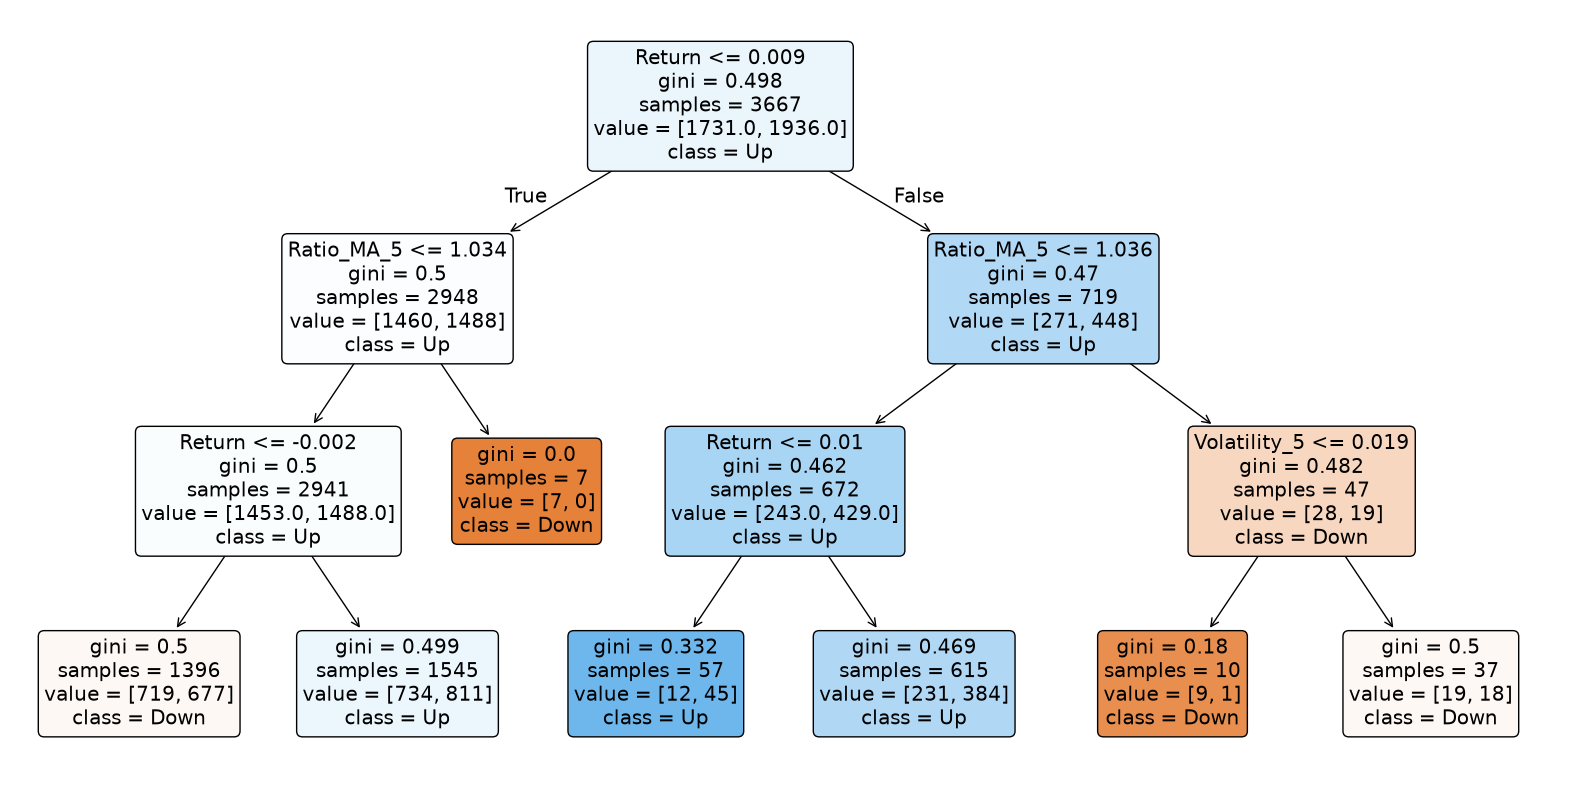

In [6]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20,10))
plot_tree(tree_model, feature_names=new_features, class_names=['Down', 'Up'], filled=True, rounded=True)
plt.show()

In [7]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
rf_model.fit(X_train_new, y_train_new)

print(f"Random Forest Accuracy: {rf_model.score(X_test_new, y_test_new):.2f}")

Random Forest Accuracy: 0.62


In [8]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
rf_model.fit(X_train_new, y_train_new)

print(f"Random Forest Accuracy: {rf_model.score(X_test_new, y_test_new):.2f}")

KeyboardInterrupt: 

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv('../data_set/row/Nifty_50_India_2000_2026.csv')

In [ ]:
print("-----Data Head-----")
print(df.head())

-----Data Head-----
        Price             Close             High               Low  \
0      Ticker             ^NSEI            ^NSEI             ^NSEI   
1        Date               NaN              NaN               NaN   
2  2007-09-17  4494.64990234375  4549.0498046875  4482.85009765625   
3  2007-09-18   4546.2001953125  4551.7998046875   4481.5498046875   
4  2007-09-19  4732.35009765625           4739.0           4550.25   

               Open Volume  
0             ^NSEI  ^NSEI  
1               NaN    NaN  
2   4518.4501953125      0  
3  4494.10009765625      0  
4           4550.25      0  


In [ ]:
print("--- Data Head ---")
print(df.info())

--- Data Head ---
<class 'pandas.DataFrame'>
RangeIndex: 4587 entries, 0 to 4586
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Price   4587 non-null   str  
 1   Close   4586 non-null   str  
 2   High    4586 non-null   str  
 3   Low     4586 non-null   str  
 4   Open    4586 non-null   str  
 5   Volume  4586 non-null   str  
dtypes: str(6)
memory usage: 215.1 KB
None
